In [17]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [18]:
# # Load the breast cancer dataset
# cancer = load_breast_cancer()
# X = cancer.data[:, :2]
# y = cancer.target

# # Save to CSV
# df = pd.DataFrame(X, columns=['mean radius', 'mean texture'])
# df['target'] = y
# df.to_csv('breast_cancer_data.csv', index=False)


In [19]:
# Load from CSV
df = pd.read_csv('breast_cancer_data.csv')
X = df[['mean radius', 'mean texture']].values
y = df['target'].values

Class counts:
 target
1    357
0    212
Name: count, dtype: int64
#############################
Class percentages:
 target
1    62.74
0    37.26
Name: proportion, dtype: float64
*****************************


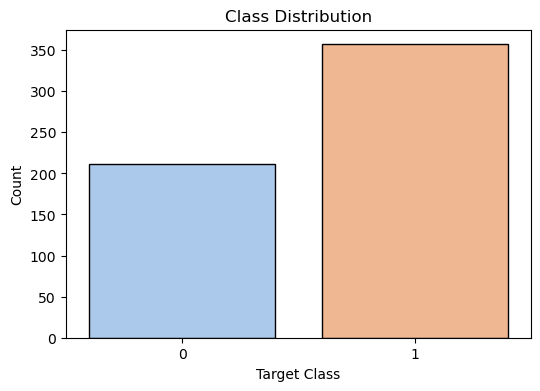

In [20]:
# Lets see how many target values are in there. 
import seaborn as sns

counts = df['target'].value_counts()
print("Class counts:\n", counts)
print('#############################')

percentages = df['target'].value_counts(normalize=True) * 100
print("Class percentages:\n", percentages.round(2))
print('*****************************')

plt.figure(figsize=(6, 4))
sns.countplot(x='target', hue='target', data=df, palette="pastel", edgecolor="k", legend=False)
plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

# Observation: We have a moderate class imbalance (~63% vs. 37%), which is common in classification problems....we can choose to ignore this
# 
# SOLUTION: Most scikit-learn classifiers (including SVC) have a class_weight parameter.
# Set class_weight='balanced' and the model will weight classes inversely proportional to their frequencies.

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the SVC model on the training data
# svm = SVC(kernel="linear", C=1)
svm = SVC(kernel="linear", C=1, class_weight='balanced') # This handle class imbalance

svm.fit(X_train, y_train)

SVC(C=1, class_weight='balanced', kernel='linear')

Confusion Matrix:
 [[39  4]
 [ 7 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        43
           1       0.94      0.90      0.92        71

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.90       114
weighted avg       0.91      0.90      0.90       114



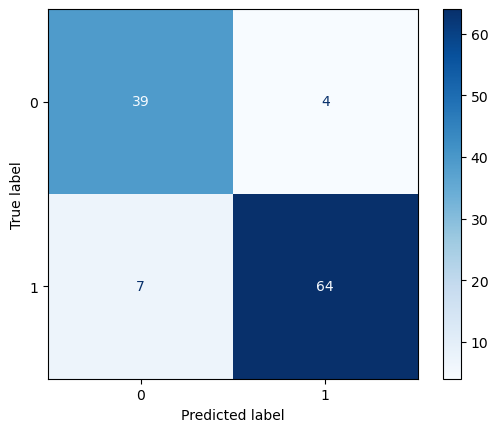

In [22]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Make predictions on the test set
y_pred = svm.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')



Confusion Matrix (Percentages):
 [[34.21  3.51]
 [ 6.14 56.14]]


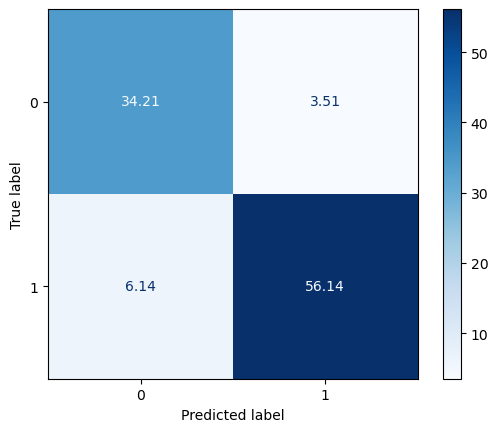

In [23]:
# I want to see the percentages:
import numpy as np

cm_percent = cm.astype('float') / cm.sum() * 100  # Convert to percentage

print("\nConfusion Matrix (Percentages):\n", np.round(cm_percent, 2))

# Display the confusion matrix visually (percentages)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=svm.classes_)
disp.plot(cmap='Blues', values_format=".2f")  # .2f to show two decimal places


w: [-0.68089635 -0.1733731 ]
Hyperplane equation: -0.6809 * x + -0.1734 * y + 13.0991 = 0


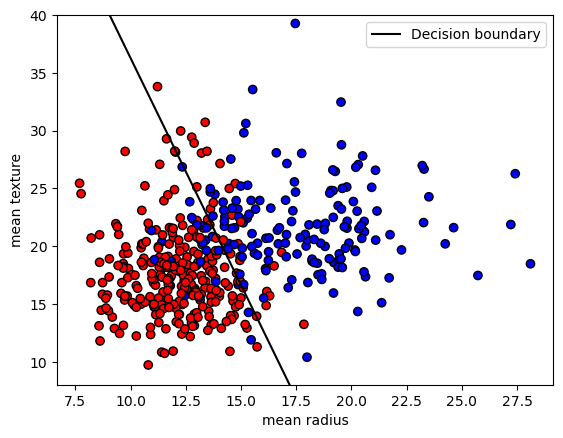

In [24]:
# Lets plot the hyperplane

import numpy as np

# Coefficients and intercept
w = svm.coef_[0]
b = svm.intercept_[0]

print(f"w: {w}")
print(f"Hyperplane equation: {w[0]:.4f} * x + {w[1]:.4f} * y + {b:.4f} = 0")

# Plot decision boundary manually
x_vals = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
y_vals = -(w[0] / w[1]) * x_vals - (b / w[1])

# plt.figure(figsize=(8, 6))  # Increase figure size
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", edgecolors="k")
plt.plot(x_vals, y_vals, 'k-', label="Decision boundary")
plt.xlabel("mean radius")
plt.ylabel("mean texture")
plt.ylim(8, 40)
plt.legend()
plt.show()


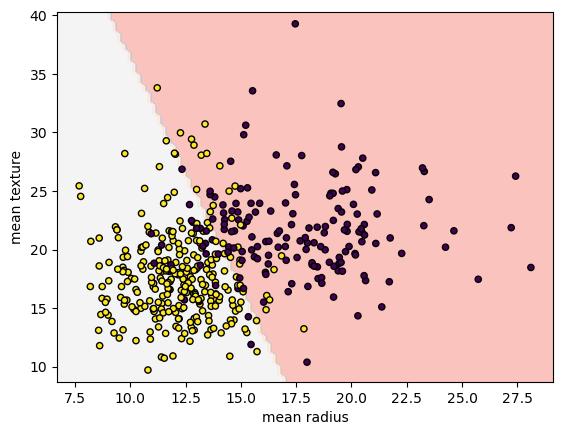

In [25]:
# Decision Boundary (using training data for fitting boundary)
DecisionBoundaryDisplay.from_estimator(
    svm,
    X_train,
    response_method="predict",
    alpha=0.8,
    cmap="Pastel1",
    xlabel="mean radius",
    ylabel="mean texture",
)

# Plot training points
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train,
            s=20, edgecolors="k")
plt.show()